In [1]:
import os
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, ConcatDataset, random_split
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, f1_score
import numpy as np
from PIL import Image

In [14]:
train_normal=len(os.listdir('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/NORMAL'))
train_pneumonia=len(os.listdir('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA'))
print(f'Normal: {train_normal}, Pnuemonia: {train_pneumonia}')

Normal: 1341, Pnuemonia: 3875


In [15]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [16]:
# Increasing validation instances
train_raw = datasets.ImageFolder('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train')
val_raw = datasets.ImageFolder('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val')
full_train = ConcatDataset([train_raw, val_raw])
train_size=int(0.8*len(full_train))
val_size=len(full_train)-train_size
train_subset, val_subset = random_split(full_train, [train_size, val_size])
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, idx):
        x, y = self.subset[idx]
        return self.transform(x), y
    def __len__(self):
        return len(self.subset)
        
train_dataset = TransformSubset(train_subset, train_transform)
val_dataset = TransformSubset(val_subset, val_transform)
test_dataset = datasets.ImageFolder('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test',
                                   transform=val_transform)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader= DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader= DataLoader(test_dataset, batch_size=32, shuffle=False)

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

In [8]:
model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
for p in model.parameters():
    p.requires_grad = False
num_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2)
)
model.load_state_dict(torch.load('/kaggle/input/models/adyanmukadam/best-densenet-pth/pytorch/default/1/final_chest_xray_model.pth'))
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval();

In [7]:
for name, layer in model.named_modules():
    if isinstance(layer, nn.Conv2d):
        print(name)

features.conv0
features.denseblock1.denselayer1.conv1
features.denseblock1.denselayer1.conv2
features.denseblock1.denselayer2.conv1
features.denseblock1.denselayer2.conv2
features.denseblock1.denselayer3.conv1
features.denseblock1.denselayer3.conv2
features.denseblock1.denselayer4.conv1
features.denseblock1.denselayer4.conv2
features.denseblock1.denselayer5.conv1
features.denseblock1.denselayer5.conv2
features.denseblock1.denselayer6.conv1
features.denseblock1.denselayer6.conv2
features.transition1.conv
features.denseblock2.denselayer1.conv1
features.denseblock2.denselayer1.conv2
features.denseblock2.denselayer2.conv1
features.denseblock2.denselayer2.conv2
features.denseblock2.denselayer3.conv1
features.denseblock2.denselayer3.conv2
features.denseblock2.denselayer4.conv1
features.denseblock2.denselayer4.conv2
features.denseblock2.denselayer5.conv1
features.denseblock2.denselayer5.conv2
features.denseblock2.denselayer6.conv1
features.denseblock2.denselayer6.conv2
features.denseblock2.de

In [9]:
target_layer = model.features.denseblock4.denselayer16.conv2

In [12]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model=model
        self.activations=None
        self.gradients=None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations=output.detach()

    def save_gradient(self, modeule, grad_input, grad_output):
        self.gradients=grad_output[0].detach()

    def generate(self, input, target_class):
        output=self.model(input)

        self.model.zero_grad()
        output[:, target_class].backward()

        weights=self.gradients.mean(dim=(2, 3), keepdim=True)
        cam=(weights*self.activations).sum(dim=1, keepdim=True)
        cam=torch.relu(cam)
        cam=(cam-cam.min())/cam.max()
        return cam.squeeze().cpu().numpy()

In [13]:
target_layer = model.features.denseblock4.denselayer16.conv2
gradcam = GradCAM(model, target_layer)

In [18]:
test_dataset.classes

['NORMAL', 'PNEUMONIA']

In [31]:
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    image = images[0].unsqueeze(0)
    label = labels[0].item()
    break
with torch.no_grad():
    output = model(image)
    predicted_class = output.argmax(dim=1).item()

print(f'True label: {label}, Predicted: {predicted_class}')

# enable gradients for target layer
for param in model.features.denseblock4.parameters():
    param.requires_grad = True

model.eval()
cam = gradcam.generate(image, predicted_class)
print(cam.shape)

True label: 0, Predicted: 0
(7, 7)


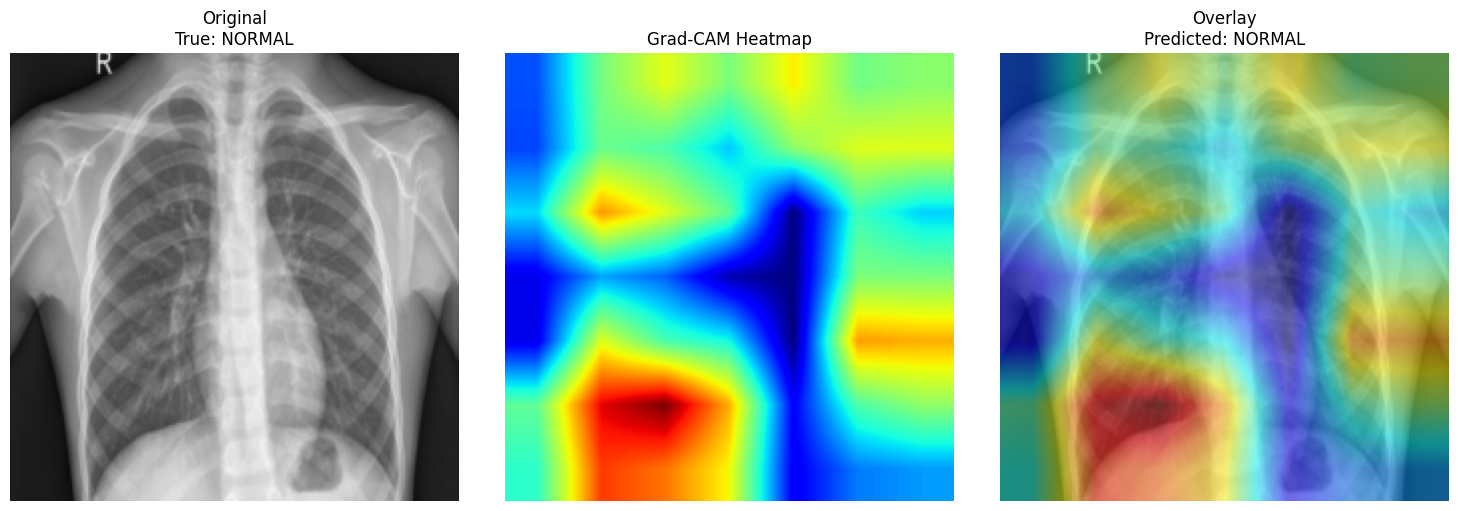

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualize_gradcam(image_tensor, cam, true_label, predicted_label, class_names):
    # undo normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = image_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    # resize CAM to 224x224
    cam_resized = cv2.resize(cam, (224, 224))
    
    # convert to heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    
    # overlay
    overlay = 0.5 * img + 0.5 * heatmap
    overlay = np.clip(overlay, 0, 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'Original\nTrue: {class_names[true_label]}')
    axes[0].axis('off')
    
    axes[1].imshow(cam_resized, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap')
    axes[1].axis('off')
    
    axes[2].imshow(overlay)
    axes[2].set_title(f'Overlay\nPredicted: {class_names[predicted_label]}')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_gradcam(image, cam, label, predicted_class, test_dataset.classes)

True: 1, Predicted: 1


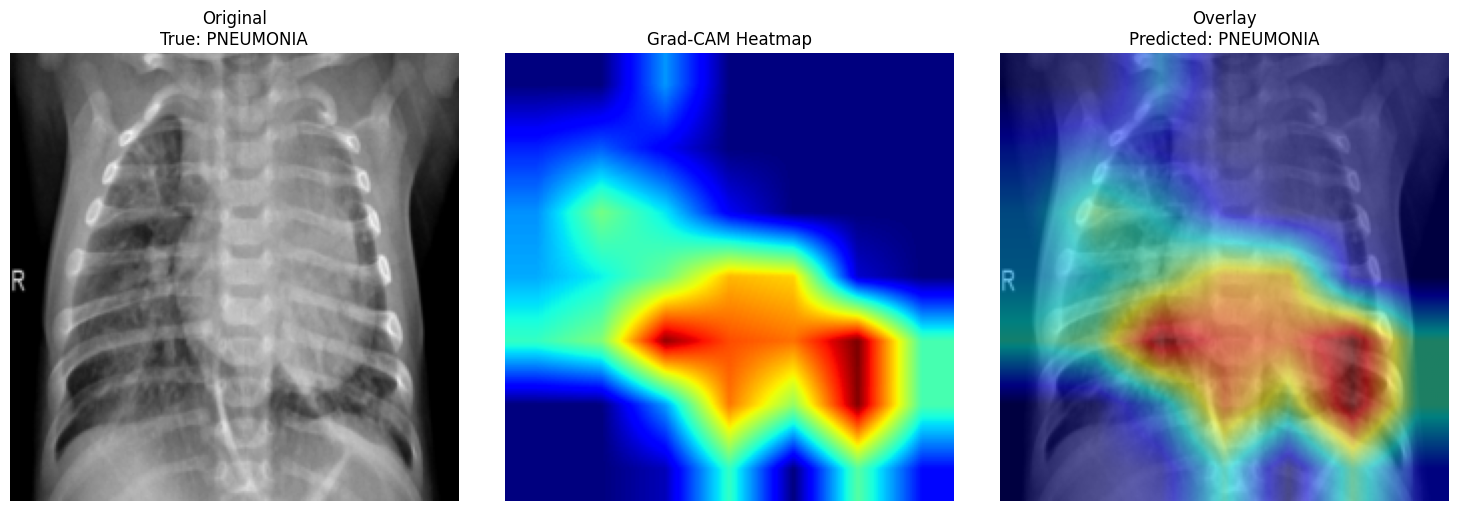

In [29]:
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    # find a pneumonia case (label == 1)
    pneumonia_idx = (labels == 1).nonzero(as_tuple=True)[0]
    if len(pneumonia_idx) > 0:
        image = images[pneumonia_idx[0]].unsqueeze(0)
        label = labels[pneumonia_idx[0]].item()
        break

with torch.no_grad():
    output = model(image)
    predicted_class = output.argmax(dim=1).item()

print(f'True: {label}, Predicted: {predicted_class}')
cam = gradcam.generate(image, predicted_class)
visualize_gradcam(image, cam, label, predicted_class, test_dataset.classes)

In [34]:
correct_pneumonia=[]
correct_normal=[]
misclassified=[]

model.eval()
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    with torch.no_grad():
        outputs=model(images)
        predicted=outputs.argmax(dim=1)

    for i in range(len(labels)):
        true=labels[i].item()
        pred=predicted[i].item()
        img=images[i].unsqueeze(0) 

        if pred==true==1 and len(correct_pneumonia)<3:
            correct_pneumonia.append((img, true, pred))
        elif pred==true==0 and len(correct_normal)<3:
            correct_normal.append((img, true, pred))
        elif pred!=true and len(misclassified)<2:
            misclassified.append((img, true, pred))

    if len(correct_pneumonia)==3 and len(correct_normal)==3 and len(misclassified)==2:
        break
all_cases=correct_pneumonia+correct_normal+misclassified

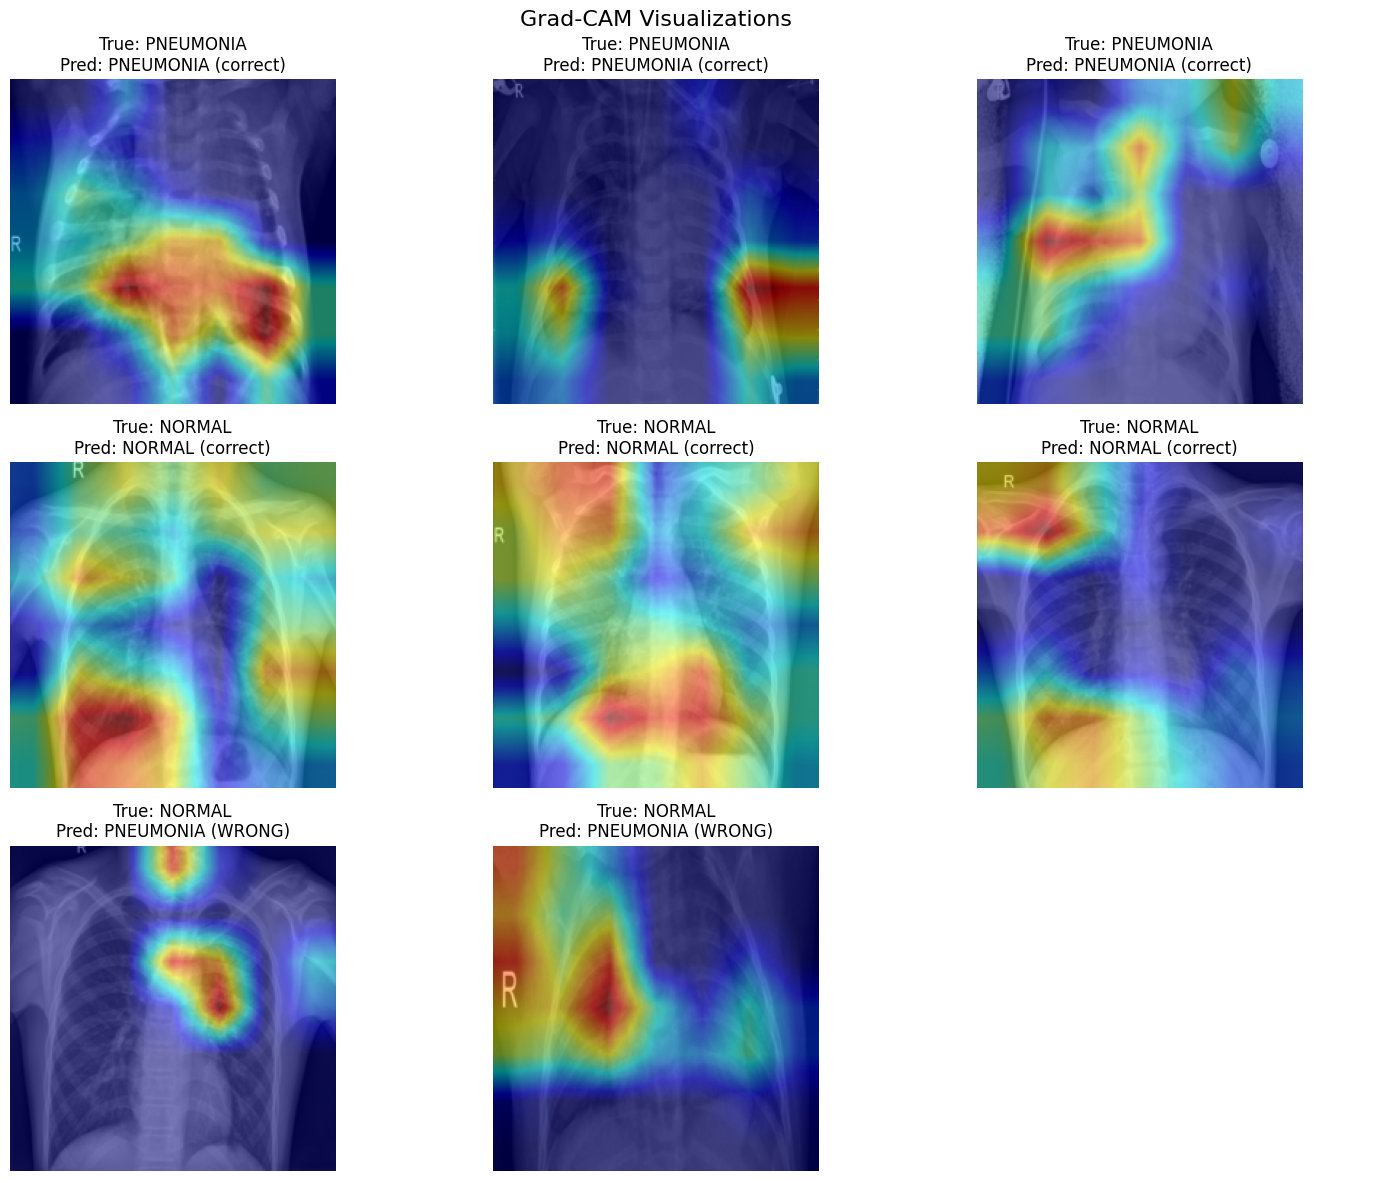

In [38]:
def visualize_gradcam(image_tensor):
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()  # makes it easier to index as 1D

    for idx, (img, true, pred) in enumerate(all_cases):
        # generate CAM for this image
        cam = gradcam.generate(img, pred)
        
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        display_img = img.squeeze().cpu().numpy().transpose(1, 2, 0)
        display_img = std * display_img + mean
        display_img = np.clip(display_img, 0, 1)
        
        cam_resized = cv2.resize(cam, (224, 224))
        heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        overlay = np.clip(0.5 * display_img + 0.5 * heatmap, 0, 1)
        
        axes[idx].imshow(overlay)
        status = 'correct' if true == pred else 'WRONG'
        axes[idx].set_title(f'True: {test_dataset.classes[true]}\nPred: {test_dataset.classes[pred]} ({status})')
        axes[idx].axis('off')
    
    axes[8].axis('off')
    
    plt.suptitle('Grad-CAM Visualizations', fontsize=16)
    plt.tight_layout()
    plt.savefig('gradcam_visualization.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

visualize_gradcam(all_cases)